In [40]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


# Ambriosio - Tortorelli Approximation

In [ ]:
# Parameters

grid = np.arange(-1, 1.01, 0.01)
delta_x = 0.01
eps = 0.1
b = 5
a = 2


In [ ]:
# Define g

g = np.where(grid >= 0, 1.0, -1.0)    # g is defined
g_mid = (g[:-1]+ g[1:]) / 2 # midpoints of g for integration


In [ ]:
# Set-up

def weighted_sum(u, alpha):
    weights = (1 - (alpha[:-1] + alpha [1:])/2) ** 2
    diffs = u[1:] - u[:-1]   
    return 1/2 * (cp.sum(cp.multiply(weights, cp.square(diffs))) / delta_x)

def Argmin_u_update(alpha):
    u = cp.Variable(201)
    u_1 = u[:101]
    u_2 = u[101:-1]
    objective = cp.Minimize(weighted_sum(u, alpha) + delta_x * b * cp.sum_squares((u[:-1]+u[1:])/2 - g_mid))
    prob = cp.Problem(objective)
    prob.solve()
    return u.value

def Argmin_alpha_update(u, beta, w, rho):
    alpha = cp.Variable(201)
    objective = cp.Minimize(weighted_sum(u, alpha) + rho/2 * cp.sum_squares(alpha - beta + w))
    constraints = [alpha[0] == 0, alpha >= 0, alpha <= 1]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return alpha.value

def Argmin_beta_update(alpha, w, rho):
    beta = cp.Variable(201)
    objective = cp.Minimize(a/2 * (delta_x / (4 * eps) * cp.sum_squares(beta[:-1] + beta[1:]) + eps / delta_x * cp.sum_squares(beta[1:] - beta[:-1])) + rho/2 * cp.sum_squares(alpha - beta + w))
    constraints = [beta[0] == 0, beta >= 0, beta <= 1]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return beta.value




In [116]:
# ADMM

alpha = np.zeros(201)
beta = np.zeros(201)
w = np.zeros(201)

rho = 10

r_norm = []
s_norm = []

r_tol = 10e-4
s_tol = 10e-4

r_new = 10e5
s_new = 10e5

num_iter = 0

while (r_tol < r_new or s_tol < s_new) and num_iter < 1000:
    beta_old = beta.copy()
    u = Argmin_u_update(alpha) # u - update
    alpha = Argmin_alpha_update(u, beta, w, rho) # alpha  - update
    beta = Argmin_beta_update(alpha, w, rho) # beta - update
    w = w + alpha - beta # dual variable update (scaled form)

    r = alpha - beta # primal residual
    r_new = np.linalg.norm(r)
    r_norm.append(r_new)

    s = rho * (beta - beta_old) # dual redisual
    s_new = np.linalg.norm(s)
    s_norm.append(s_new)

    num_iter +=1



r_norm = np.array(r_norm)
s_norm = np.array(s_norm)
print(f"{num_iter} iterations needed for convergence")

270 iterations needed for convergence


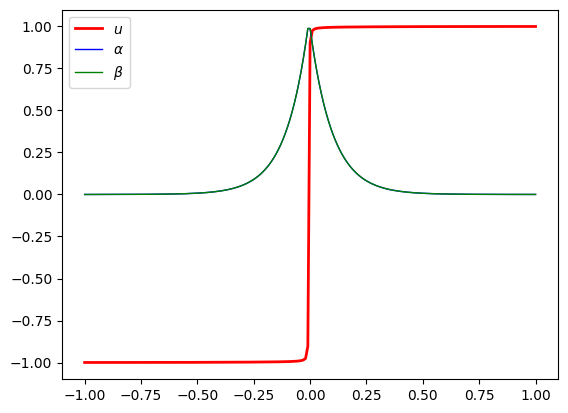

In [ ]:
# Plotting u, alpha and beta

plt.close('all')
fig, ax = plt.subplots()
ax.plot(grid, u, linewidth = 2, color = 'red', label = r'$u$')
ax.plot(grid, alpha, linewidth = 1, color = 'blue', label = r'$\alpha$')
ax.plot(grid, beta, linewidth = 1, color = 'green', label = r'$\beta$')
ax.legend()



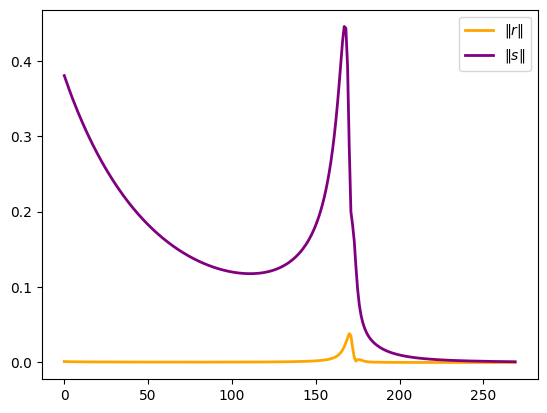

In [ ]:
#Plotting primal and dual residuals

plt.close('all')
fig, ax = plt.subplots()
ax.plot(r_norm, linewidth = 2, color = 'orange', label = r'$\|r\|$')
ax.plot(s_norm, linewidth = 2, color = 'purple', label = r'$\|s\|$')
ax.legend()

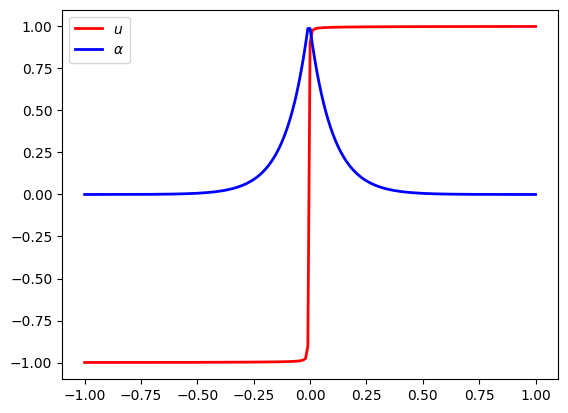

In [119]:
# Alternating Minimization

alpha = np.zeros(201)

def Argmin_alpha_update_AM(u):
    alpha = cp.Variable(201)
    u_1 = u[:101]
    u_2 = u[101:-1]
    objective = cp.Minimize(weighted_sum(u, alpha) + delta_x * b * cp.sum_squares((u[:-1]+u[1:])/2 - g_mid) 
                            + a/2 * (delta_x / (4 * eps) * cp.sum_squares(alpha[:-1] + alpha[1:]) + eps / delta_x * cp.sum_squares(alpha[1:] - alpha[:-1])))
    constraints = [alpha[0] == 0, alpha >= 0, alpha <= 1]
    prob = cp. Problem(objective, constraints)
    prob.solve()
    return alpha.value



for _ in range(50):
    u = Argmin_u_update(alpha)
    alpha = Argmin_alpha_update_AM(u)

plt.close('all')
fig, ax = plt.subplots()
ax.plot(grid, u, linewidth = 2, color = 'red', label = r'$u$')
ax.plot(grid, alpha , linewidth = 2, color = 'blue', label = r'$\alpha$')
ax.legend()


